In [13]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Load dataset
df = pd.read_csv('dataset.csv')

# Kolom gejala
kolom_gejala = ['Symptom_1','Symptom_2','Symptom_3','Symptom_4',
                'Symptom_5','Symptom_6','Symptom_7','Symptom_8',
                'Symptom_9','Symptom_10','Symptom_11','Symptom_12',
                'Symptom_13','Symptom_14','Symptom_15','Symptom_16',
                'Symptom_17']

# Gabungkan semua kolom gejala jadi satu teks
def gabung_gejala(baris):
    gejala = []
    for col in kolom_gejala:
        nilai = baris[col]
        if pd.notna(nilai):
            gejala.append(str(nilai).strip().replace('_', ' '))
    return ' '.join(gejala)

df['Symptoms_gabung'] = df.apply(gabung_gejala, axis=1)

print("=== DATASET BERHASIL DIMUAT ===")
print(f"Total baris : {len(df)}")
print(f"Total kolom : {len(df.columns)}")
print("\nContoh 3 baris pertama:")
print(df[['Disease', 'Symptoms_gabung']].head(3).to_string())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== DATASET BERHASIL DIMUAT ===
Total baris : 4920
Total kolom : 19

Contoh 3 baris pertama:
            Disease                                             Symptoms_gabung
0  Fungal infection  itching skin rash nodal skin eruptions dischromic  patches
1  Fungal infection          skin rash nodal skin eruptions dischromic  patches
2  Fungal infection            itching nodal skin eruptions dischromic  patches


In [14]:

penyakit_dipilih = [
    'Diabetes',
    'Hypertension',
    'Bronchial Asthma',
    'Paralysis (brain hemorrhage)'
]

df_filter = df[df['Disease'].isin(penyakit_dipilih)].copy()
df_filter = df_filter.reset_index(drop=True)

# Verifikasi
print("=== HASIL FILTER ===")
print(f"Total data : {len(df_filter)} baris")
print("\nJumlah per penyakit:")
print(df_filter['Disease'].value_counts())

if len(df_filter['Disease'].unique()) < 4:
    print("\n⚠ PERINGATAN: Kurang dari 4 penyakit terbaca!")
    print("Penyakit yang ditemukan:", df_filter['Disease'].unique())
else:
    print("\n✓ Semua 4 penyakit berhasil difilter")

print("\nContoh data:")
print(df_filter[['Disease', 'Symptoms_gabung']].head(8).to_string())

=== HASIL FILTER ===
Total data : 240 baris

Jumlah per penyakit:
Disease
Bronchial Asthma                120
Paralysis (brain hemorrhage)    120
Name: count, dtype: int64

⚠ PERINGATAN: Kurang dari 4 penyakit terbaca!
Penyakit yang ditemukan: <StringArray>
['Bronchial Asthma', 'Paralysis (brain hemorrhage)']
Length: 2, dtype: str

Contoh data:
            Disease                                                       Symptoms_gabung
0  Bronchial Asthma  fatigue cough high fever breathlessness family history mucoid sputum
1  Bronchial Asthma          cough high fever breathlessness family history mucoid sputum
2  Bronchial Asthma        fatigue high fever breathlessness family history mucoid sputum
3  Bronchial Asthma             fatigue cough breathlessness family history mucoid sputum
4  Bronchial Asthma                 fatigue cough high fever family history mucoid sputum
5  Bronchial Asthma                 fatigue cough high fever breathlessness mucoid sputum
6  Bronchial Asthma    

In [15]:
# 4 penyakit kronis yang dipilih
# Nama HARUS persis sama dengan yang ada di dataset
penyakit_dipilih = [
    'Diabetes',
    'Hypertension',
    'Bronchial Asthma',
    'Paralysis (brain hemorrhage)'
]

# Filter
df_filter = df[df['Disease'].isin(penyakit_dipilih)].copy()
df_filter = df_filter.reset_index(drop=True)

# Verifikasi
print("=== HASIL FILTER ===")
print(f"Total data : {len(df_filter)} baris")
print("\nJumlah per penyakit:")
print(df_filter['Disease'].value_counts())

# Pastikan 4 penyakit terbaca
if len(df_filter['Disease'].unique()) < 4:
    print("\n⚠ PERINGATAN: Kurang dari 4 penyakit terbaca!")
    print("Penyakit yang ditemukan:", df_filter['Disease'].unique())
else:
    print("\n✓ Semua 4 penyakit berhasil difilter")

print("\nContoh data:")
print(df_filter[['Disease', 'Symptoms_gabung']].head(8).to_string())

=== HASIL FILTER ===
Total data : 240 baris

Jumlah per penyakit:
Disease
Bronchial Asthma                120
Paralysis (brain hemorrhage)    120
Name: count, dtype: int64

⚠ PERINGATAN: Kurang dari 4 penyakit terbaca!
Penyakit yang ditemukan: <StringArray>
['Bronchial Asthma', 'Paralysis (brain hemorrhage)']
Length: 2, dtype: str

Contoh data:
            Disease                                                       Symptoms_gabung
0  Bronchial Asthma  fatigue cough high fever breathlessness family history mucoid sputum
1  Bronchial Asthma          cough high fever breathlessness family history mucoid sputum
2  Bronchial Asthma        fatigue high fever breathlessness family history mucoid sputum
3  Bronchial Asthma             fatigue cough breathlessness family history mucoid sputum
4  Bronchial Asthma                 fatigue cough high fever family history mucoid sputum
5  Bronchial Asthma                 fatigue cough high fever breathlessness mucoid sputum
6  Bronchial Asthma    

In [16]:
# Cek nama penyakit yang mengandung kata Diabetes dan Hypertension
print("=== CEK NAMA PERSIS DI DATASET ===")
semua_penyakit = df['Disease'].unique()
for p in sorted(semua_penyakit):
    if any(kata in p for kata in ['Diabetes', 'Hypertension', 'Asthma', 'Paralysis']):
        print(repr(p))  # repr() akan tampilkan spasi tersembunyi

=== CEK NAMA PERSIS DI DATASET ===
'Bronchial Asthma'
'Diabetes '
'Hypertension '
'Paralysis (brain hemorrhage)'


In [17]:
# Bersihkan spasi tersembunyi di kolom Disease
df['Disease'] = df['Disease'].str.strip()

# 4 penyakit pilihan
penyakit_dipilih = [
    'Diabetes',
    'Hypertension',
    'Bronchial Asthma',
    'Paralysis (brain hemorrhage)'
]

# Filter
df_filter = df[df['Disease'].isin(penyakit_dipilih)].copy()
df_filter = df_filter.reset_index(drop=True)

# Verifikasi
print("=== HASIL FILTER ===")
print(f"Total data : {len(df_filter)} baris")
print("\nJumlah per penyakit:")
print(df_filter['Disease'].value_counts())

if len(df_filter['Disease'].unique()) < 4:
    print("\n⚠ MASIH KURANG DARI 4 — kirimkan output repr di atas ke saya")
else:
    print("\n✓ Semua 4 penyakit berhasil difilter — lanjut ke Sel 3")

=== HASIL FILTER ===
Total data : 480 baris

Jumlah per penyakit:
Disease
Diabetes                        120
Bronchial Asthma                120
Hypertension                    120
Paralysis (brain hemorrhage)    120
Name: count, dtype: int64

✓ Semua 4 penyakit berhasil difilter — lanjut ke Sel 3


In [18]:
from nltk.corpus import stopwords
import re

stop_en = set(stopwords.words('english'))

kata_penting = {'no','not','loss','gain','shortness',
                'blurred','rapid','high','low','severe',
                'weakness','numbness','difficulty'}
stop_en = stop_en - kata_penting

def preprocessing(teks):
    teks = str(teks).lower()
    teks = re.sub(r'[^a-z\s]', '', teks)
    token = [t for t in teks.split() if t not in stop_en]
    return ' '.join(token).strip()

df_filter['Symptoms_clean'] = df_filter['Symptoms_gabung'].apply(preprocessing)

print("=== PERBANDINGAN PREPROCESSING ===")
for i in range(4):
    print(f"\nPenyakit : {df_filter['Disease'].iloc[i]}")
    print(f"Asli     : {df_filter['Symptoms_gabung'].iloc[i]}")
    print(f"Bersih   : {df_filter['Symptoms_clean'].iloc[i]}")

=== PERBANDINGAN PREPROCESSING ===

Penyakit : Diabetes
Asli     : fatigue weight loss restlessness lethargy irregular sugar level blurred and distorted vision obesity excessive hunger increased appetite polyuria
Bersih   : fatigue weight loss restlessness lethargy irregular sugar level blurred distorted vision obesity excessive hunger increased appetite polyuria

Penyakit : Diabetes
Asli     : fatigue weight loss restlessness lethargy irregular sugar level blurred and distorted vision obesity excessive hunger increased appetite polyuria
Bersih   : fatigue weight loss restlessness lethargy irregular sugar level blurred distorted vision obesity excessive hunger increased appetite polyuria

Penyakit : Diabetes
Asli     : weight loss restlessness lethargy irregular sugar level blurred and distorted vision obesity excessive hunger increased appetite polyuria
Bersih   : weight loss restlessness lethargy irregular sugar level blurred distorted vision obesity excessive hunger increased appeti

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df_filter['Symptoms_clean']
y = df_filter['Disease']

print("Label yang ada:", y.unique())
print("Jumlah total data:", len(y))

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(X)

print(f"\nJumlah fitur TF-IDF : {X_tfidf.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data training       : {X_train.shape[0]} baris")
print(f"Data testing        : {X_test.shape[0]} baris")

print("\nDistribusi training:")
print(y_train.value_counts())
print("\nDistribusi testing:")
print(y_test.value_counts())

Label yang ada: <StringArray>
['Diabetes', 'Bronchial Asthma', 'Hypertension',
 'Paralysis (brain hemorrhage)']
Length: 4, dtype: str
Jumlah total data: 480

Jumlah fitur TF-IDF : 93
Data training       : 384 baris
Data testing        : 96 baris

Distribusi training:
Disease
Hypertension                    96
Paralysis (brain hemorrhage)    96
Diabetes                        96
Bronchial Asthma                96
Name: count, dtype: int64

Distribusi testing:
Disease
Hypertension                    24
Bronchial Asthma                24
Paralysis (brain hemorrhage)    24
Diabetes                        24
Name: count, dtype: int64


Melatih model SVM...

╔══════════════════════════════════════════╗
║   AKURASI : 100.00%                    ║
║   Waktu   : 0.28 detik                 ║
╚══════════════════════════════════════════╝

=== CLASSIFICATION REPORT ===
                              precision    recall  f1-score   support

            Bronchial Asthma       1.00      1.00      1.00        24
                    Diabetes       1.00      1.00      1.00        24
                Hypertension       1.00      1.00      1.00        24
Paralysis (brain hemorrhage)       1.00      1.00      1.00        24

                    accuracy                           1.00        96
                   macro avg       1.00      1.00      1.00        96
                weighted avg       1.00      1.00      1.00        96



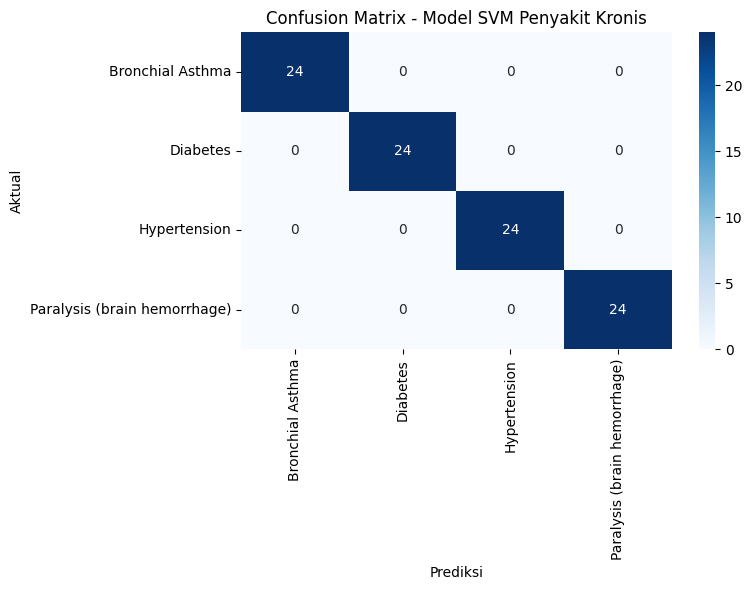


✓ Confusion matrix disimpan sebagai confusion_matrix_final.png


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Melatih model SVM...")
mulai = time.time()
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)
durasi = time.time() - mulai

y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n╔══════════════════════════════════════════╗")
print(f"║   AKURASI : {akurasi*100:.2f}%                    ║")
print(f"║   Waktu   : {durasi:.2f} detik                 ║")
print(f"╚══════════════════════════════════════════╝")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix - Model SVM Penyakit Kronis')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

print("\n✓ Confusion matrix disimpan sebagai confusion_matrix_final.png")

In [21]:
import joblib
import json

joblib.dump(model, 'model_final.pkl')
joblib.dump(tfidf, 'tfidf_final.pkl')

config = {
    'label_mapping': {
        'Diabetes'                     : 'Diabetes',
        'Hypertension'                 : 'Hipertensi',
        'Bronchial Asthma'             : 'Asma',
        'Paralysis (brain hemorrhage)' : 'Stroke'
    }
}
with open('config_model.json', 'w') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("=== SEMUA FILE TERSIMPAN ===")
print("✓ model_final.pkl       → model SVM terlatih")
print("✓ tfidf_final.pkl       → vectorizer TF-IDF")
print("✓ config_model.json     → mapping label Indonesia")
print("\nKetiga file ini akan dipakai di API Flask selanjutnya")

=== SEMUA FILE TERSIMPAN ===
✓ model_final.pkl       → model SVM terlatih
✓ tfidf_final.pkl       → vectorizer TF-IDF
✓ config_model.json     → mapping label Indonesia

Ketiga file ini akan dipakai di API Flask selanjutnya


In [22]:
from deep_translator import GoogleTranslator

mapping_id = {
    'Diabetes'                     : 'Diabetes',
    'Hypertension'                 : 'Hipertensi',
    'Bronchial Asthma'             : 'Asma',
    'Paralysis (brain hemorrhage)' : 'Stroke'
}

def prediksi(gejala_input):
    try:
        gejala_en = GoogleTranslator(source='id', target='en').translate(gejala_input)
    except:
        gejala_en = gejala_input

    gejala_bersih = preprocessing(gejala_en)
    vektor = tfidf.transform([gejala_bersih])
    hasil = model.predict(vektor)[0]
    proba = model.predict_proba(vektor)[0]

    print(f"Input    : {gejala_input}")
    print(f"Inggris  : {gejala_en}")
    print(f"Prediksi : {mapping_id.get(hasil, hasil)}")
    print("\nProbabilitas:")
    for kelas, p in sorted(zip(model.classes_, proba),
                           key=lambda x: x[1], reverse=True):
        bar = '█' * int(p * 30)
        print(f"  {mapping_id.get(kelas, kelas):<30} {bar} {p*100:.1f}%")
    print()

print("=" * 50)
print("UJI 1 — Gejala Asma")
prediksi("sesak napas, batuk, dada berat, mengi")

print("=" * 50)
print("UJI 2 — Gejala Diabetes")
prediksi("sering kencing, sering haus, kelelahan, penglihatan kabur")

print("=" * 50)
print("UJI 3 — Gejala Stroke")
prediksi("lumpuh, bicara pelo, mati rasa di wajah, sakit kepala parah")

print("=" * 50)
print("UJI 4 — Gejala Hipertensi")
prediksi("sakit kepala, jantung berdebar, pusing, nyeri dada")

UJI 1 — Gejala Asma
Input    : sesak napas, batuk, dada berat, mengi
Inggris  : shortness of breath, cough, heavy chest, wheezing
Prediksi : Asma

Probabilitas:
  Asma                           ███████████ 37.1%
  Hipertensi                     ██████████ 36.1%
  Stroke                         ████ 16.0%
  Diabetes                       ███ 10.8%

UJI 2 — Gejala Diabetes
Input    : sering kencing, sering haus, kelelahan, penglihatan kabur
Inggris  : frequent urination, frequent thirst, fatigue, blurred vision
Prediksi : Diabetes

Probabilitas:
  Diabetes                       █████████████ 44.5%
  Asma                           ███████ 23.8%
  Stroke                         ████ 16.5%
  Hipertensi                     ████ 15.1%

UJI 3 — Gejala Stroke
Input    : lumpuh, bicara pelo, mati rasa di wajah, sakit kepala parah
Inggris  : paralyzed, slurred speech, facial numbness, severe headache
Prediksi : Stroke

Probabilitas:
  Stroke                         ████████████ 42.8%
  Hipertensi